# Objective
Analyze global EV data to compare EV sales vs EV stock in early adoption stages across regions, 
and identify future trends in EV penetration to understand how electric vehicles will reshape transportation.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#style settimgs
plt.style.use("ggplot")
sns.set_palette("viridis")

In [15]:
ev=pd.read_csv(r"IEA Global EV Data 2024.csv")

## Dataset overview

In [16]:
ev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12654 entries, 0 to 12653
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      12654 non-null  object 
 1   category    12654 non-null  object 
 2   parameter   12654 non-null  object 
 3   mode        12654 non-null  object 
 4   powertrain  12654 non-null  object 
 5   year        12654 non-null  int64  
 6   unit        12654 non-null  object 
 7   value       12654 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 494.4+ KB


## Exploratory Data Analysis

In [18]:
ev.describe()

,year,value
count,12654.000000,1.265400e+04
mean,2019.822112,4.273742e+05
std,5.476494,6.860498e+06
min,2010.000000,1.200000e-06
25%,2016.000000,2.000000e+00
50%,2020.000000,1.300000e+02
75%,2022.000000,5.500000e+03
max,2035.000000,4.400000e+08


In [53]:
ev["parameter"].value_counts()

EV stock                         3470
EV sales                         3372
EV sales share                   1642
EV stock share                   1529
EV charging points                918
Oil displacement Mbd              586
Oil displacement, million lge     586
Electricity demand                551
Name: parameter, dtype: int64

In [20]:
ev["region"].nunique()

54

In [21]:
ev.isnull().sum()

region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64

## Data cleaning

In [63]:
ev_filtered=ev[ev["parameter"].isin(["EV sales share","EV stock share"])]

In [49]:
ev_filtered ["value"]=ev_filtered ["value"]*100

In [50]:
ev_filtered ["value"]

1           0.65
6           3.00
13          3.40
18         16.00
25         20.00
          ...   
12641    6800.00
12644    4100.00
12645    2200.00
12647    2900.00
12649    5500.00
Name: value, Length: 1642, dtype: float64

In [64]:
 ev_pivot = ev_filtered.pivot_table(index =["region","year"],columns = "parameter",values = "value").reset_index()

In [40]:
early_stages = ev_pivot[ev_pivot["year"]<=2015]

In [99]:
top_regions = (early_stages.groupby("region")["EV sales share"].sum().sort_values(ascending=False).head(5).index)

In [100]:
top_5_regions = (ev_pivot.groupby("region")["EV sales share"].sum().sort_values(ascending=False).head(5).index)

In [101]:
 top5_data = ev_pivot[ev_pivot["region"].isin(top_5_regions)]


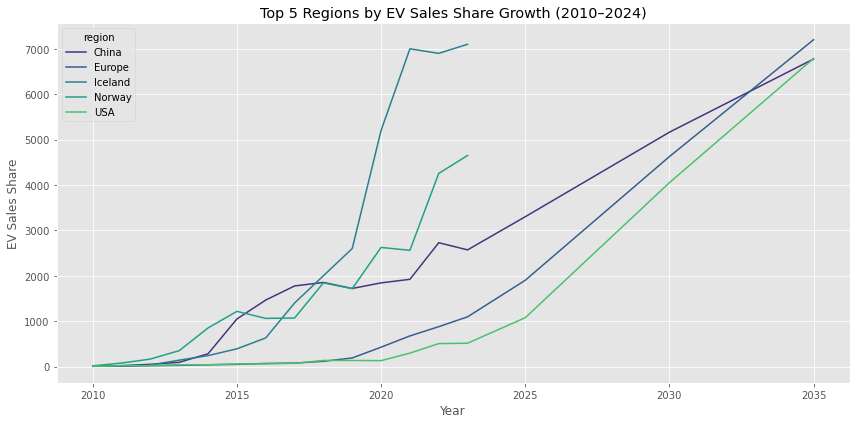

In [37]:
plt.figure(figsize=(12,6))

sns.lineplot(data=top5_data,x="year",y="EV sales share",hue="region")

plt.title("Top 5 Regions by EV Sales Share Growth (2010–2024)")
plt.xlabel("Year")
plt.ylabel("EV Sales Share")
plt.tight_layout()
plt.show()



1. EV Sales Trend Analysis
### Insight
EV sales share has increased significantly over time in top-performing regions, especially after 2020.

### Interpretation
Government incentives, charging infrastructure expansion, and consumer awareness are accelerating EV adoption globally.

In [67]:
top_5_regions = (ev_pivot.groupby("region")["EV stock share"].sum() .sort_values(ascending=False).head(5).index)

In [68]:
top5_data = ev_pivot[ev_pivot["region"].isin(top_5_regions)]

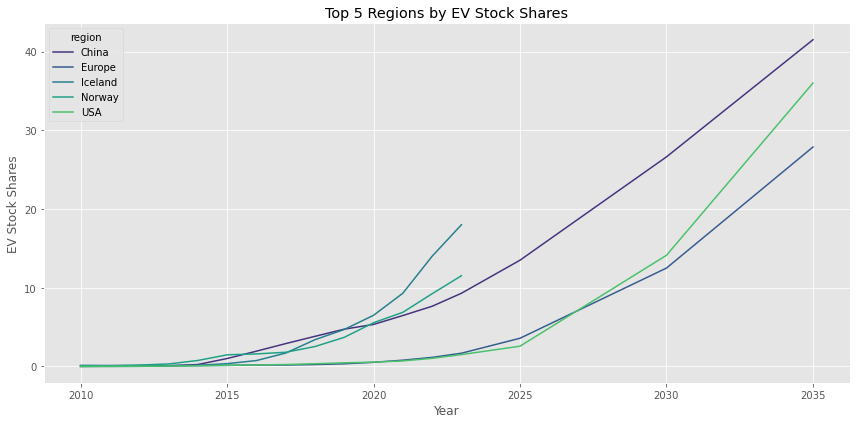

In [70]:
plt.figure(figsize=(12,6))

sns.lineplot(data=top5_data,x="year",y="EV stock share",hue="region")
plt.title("Top 5 Regions by EV Stock Shares")
plt.xlabel("Year")
plt.ylabel("EV Stock Shares")
plt.tight_layout()
plt.show()

2. EV Stock Growth Analysis
### Insight

EV stock share continues to rise steadily, indicating long-term accumulation of electric vehicles in the market.

### Interpretation

The EV ecosystem is maturing, showing that EVs are not only being purchased but retained as part of the transportation fleet.

In [153]:
ev_pivot.pivot_table(index = "region",columns= "year",values = "EV stock share").fillna(0)

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2025,2030,2035
region,,,,,,,,,,,,,,,,,
Australia,0.000000,3.900000,24.000001,46.000001,140.000004,270.000007,370.000005,520.000011,769.999996,1400.000006,1800.000072,3199.999928,5899.999738,12000.000477,0.000000,0.000000,0.0
Austria,78.999996,219.999999,329.999998,529.999994,890.000015,1400.000006,2399.999946,3799.999952,5299.999714,7500.000000,12000.000477,20999.999046,30000.000000,44000.000954,0.000000,0.000000,0.0
Belgium,81.499998,106.250000,246.999997,309.500003,984.000000,1883.499918,2840.250011,3899.249993,4955.000072,6454.999945,9582.499759,13290.000032,18344.999859,38149.999492,0.000000,0.000000,0.0
Brazil,0.000000,0.000000,0.000000,0.000000,1.600000,5.900000,8.100000,15.000000,23.690000,68.200003,82.700002,322.250005,810.000002,1302.499976,0.000000,0.000000,0.0
Bulgaria,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
Canada,0.000000,15.550000,67.400001,141.000004,272.999997,287.699996,440.666651,706.966645,1028.699986,1730.674938,4000.666627,6002.800238,9006.666926,16000.000164,0.000000,0.000000,0.0
Chile,0.000000,2.200000,3.800000,5.100000,10.000000,20.999999,29.000000,65.000001,109.999999,170.000009,219.999999,350.000001,680.000037,869.999975,0.000000,0.000000,0.0
China,159.274999,347.174993,565.499993,871.499977,2484.249966,10087.499749,19399.999753,29049.999118,38275.000006,47400.000095,53400.000036,64699.999690,76474.999487,92999.999523,135000.000000,266250.000000,415000.0
Colombia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


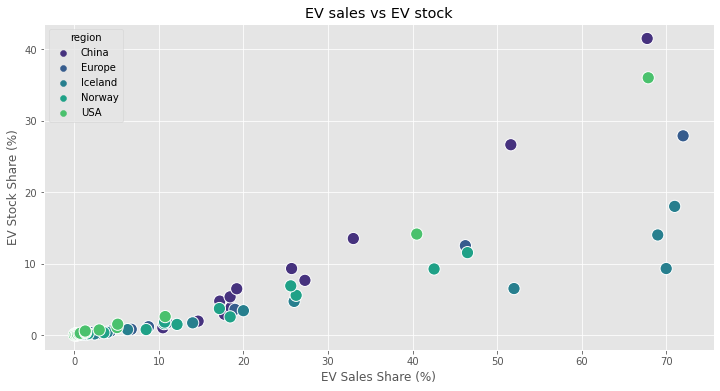

In [73]:
#Visualization of EV sales vs EV stock
plt.figure(figsize=(12,6))
sns.scatterplot(data = top5_data,x="EV sales share",y="EV stock share",hue="region",s = 150)
plt.xlabel("EV Sales Share (%)")
plt.ylabel("EV Stock Share (%)")
plt.title("EV sales vs EV stock")
plt.grid(True)
plt.show()


### Insight

Regions with higher EV sales shares generally also maintain higher EV stock shares.

### Interpretation

Strong EV sales momentum translates into sustained market penetration and long-term adoption growth.

In [88]:
top5_data = ev_pivot[
    ev_pivot["region"].isin(top_5_regions)]

In [91]:
top_5_regions = (ev_pivot.groupby("region")["adoption_gap"].sum().sort_values(ascending=False).head(5).index)

In [102]:
top5_data = ev_pivot[ev_pivot["region"].isin(top_5_regions)]

### Insight

Some regions show a large adoption gap, where EV sales are rising faster than total EV fleet penetration.

###  Interpretation

These regions are in rapid growth phases where new EV purchases are increasing faster than infrastructure and overall market saturation.

In [134]:
ev_pivot = ev_pivot.fillna(0)

In [104]:
#growth rate calculation
ev_pivot["stock_growth"]=(ev_pivot.groupby("region")["EV stock share"].pct_change()*100).fillna(0)
ev_pivot["sales_growth"]=(ev_pivot.groupby("region")["EV sales share"].pct_change()*100).fillna(0)


## Insight

Year-over-year growth rates show periods of sharp EV acceleration in leading regions.

## Interpretation

Policy interventions and technological improvements significantly influence EV market expansion rates.

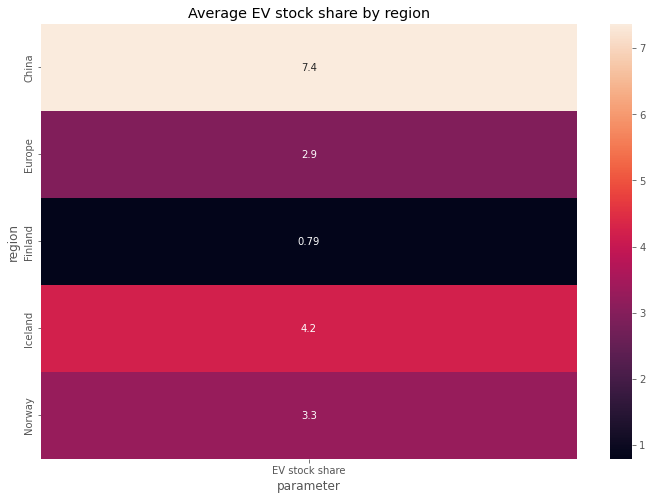

In [98]:
pivot_growth = top5_data.pivot_table(index = "region",values= "EV stock share",aggfunc="mean")
plt.figure(figsize =(12,8))
sns.heatmap(pivot_growth,annot= True)
plt.title("Average EV stock share by region")
plt.show()

## Insight

Certain regions consistently maintain high EV stock shares across years.

## Interpretation

Developed EV markets benefit from stronger infrastructure, policy support, and consumer trust in electric mobility.

# conclusion
'''1. Early Stage Insight
      In early years, EV sales are significantly higher than EV stock → indicating adoption has started but penetration is still low.
   
   2. Adoption Gap Insight
      Regions with large adoption gaps are future growth hotspots.
  
   3. Stock Growth Insight
      EV stock increases slowly but steadily → reflects vehicle lifecycle accumulation.
   
   4. Sales Trend Insight
      Sales grow faster than stock → indicates accelerating adoption.
     
5. Future Transformation Insight
    As stock increases:

Fuel demand decreases
Charging infrastructure demand increases'''